<a href="https://colab.research.google.com/github/Eikthyrnir/uam-cv-sim-to-real-interpretability/blob/main/DIMO_sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Mount Google Drive
To avoid downloading massive files every time your session disconnects, we can save the dataset to Google Drive (if you have enough space). Otherwise, you can use the local `/content/` storage, but remember it will be cleared after the session ends.

In [1]:
from google.colab import drive
import os

# Mount Google Drive (Optional but recommended if you have space)
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
PROJECT_DIR = '/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO'

os.makedirs(PROJECT_DIR, exist_ok=True)

### Step 2: Download the Dataset
Since the file is huge, you can download it using `wget`.
*Note: Replace `DIRECT_DOWNLOAD_URL_HERE` with the actual download link from the DIMO website.*

In [11]:
TAR_PATH = os.path.join(PROJECT_DIR, "dimo.tar")

In [12]:
DATASET_URL = "https://datasets.ilabt.imec.be/dimo/tar/dimo.tar"


# Download only if it doesn't exist yet
if not os.path.exists(TAR_PATH):
    !wget -O "{TAR_PATH}" "{DATASET_URL}"

--2026-05-27 19:20:14--  https://datasets.ilabt.imec.be/dimo/tar/dimo.tar
Resolving datasets.ilabt.imec.be (datasets.ilabt.imec.be)... 193.191.148.201, 2001:6a8:1d80:26::201
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14153728 (13M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo.tar’

/content/drive/MyDr 100%[===================>]  13.50M  5.44MB/s    in 2.5s    

2026-05-27 19:20:18 (5.44 MB/s) - ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo.tar’ saved [14153728/14153728]



#### Download Real-World Data (RealSense D415)
Since the project involves comparing real and synthetic data, let's start with the smallest real-world image archive (RealSense D415, 12.7 GB). Replace the URL below with the actual link to this archive.

In [ ]:
REAL_DATA_URL = "https://datasets.ilabt.imec.be/dimo/tar/real_d415.tar"
REAL_TAR_PATH = os.path.join(PROJECT_DIR, "real_d415.tar")

if not os.path.exists(REAL_TAR_PATH):
    !wget -O "{REAL_TAR_PATH}" "{REAL_DATA_URL}"

### Step 3: Extract a Small Subset & Visualize
Instead of unzipping 64GB, let's peek into the zip file, find the first 5 images, extract only them, and visualize. This saves massive amounts of time and disk space.

In [13]:
import tarfile
import matplotlib.pyplot as plt
from PIL import Image
import io
import os

def visualize_subset_from_tar(tar_filepath, num_images=4):
    if not os.path.exists(tar_filepath):
        print(f"File not found: {tar_filepath}")
        return

    # Open the tar file without extracting everything
    with tarfile.open(tar_filepath, 'r') as tar:
        # Get a list of all members (files) in the tar
        members = tar.getmembers()

        # Filter for image files (assuming jpg or png)
        image_members = [m for m in members if m.name.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"Total images found in archive: {len(image_members)}")

        if not image_members:
            print("No images found. This archive might just contain annotations or base directories.")
            return

        # Select a few images
        selected_members = image_members[:num_images]

        # Plotting
        fig, axes = plt.subplots(1, len(selected_members), figsize=(15, 5))
        if len(selected_members) == 1:
            axes = [axes]

        for ax, member in zip(axes, selected_members):
            # Extract the single image to memory
            f = tar.extractfile(member)
            if f is not None:
                img = Image.open(io.BytesIO(f.read()))
                ax.imshow(img)
                ax.set_title(member.name.split('/')[-1])
                ax.axis('off')
        plt.tight_layout()
        plt.show()

Total images found in archive: 15600


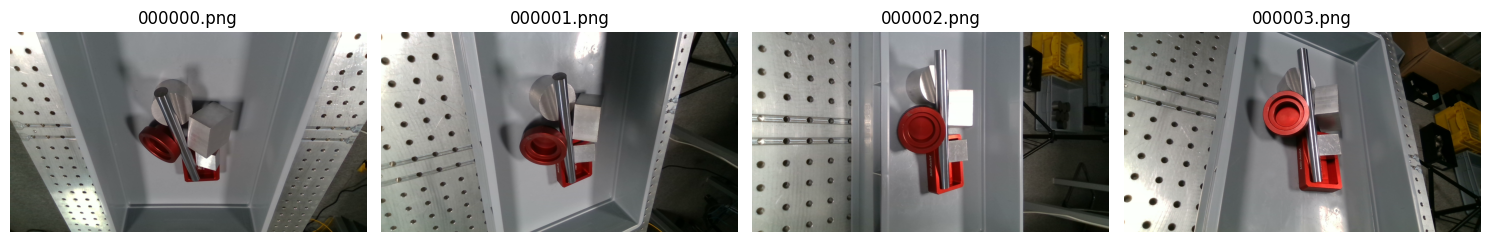

In [18]:
# Once downloaded, you can visualize a few images from it directly!
visualize_subset_from_tar(REAL_TAR_PATH, num_images=4)

# Upzip

In [33]:
!mkdir -p /content/DIMO
!tar -xf /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo.tar -C /content/DIMO

tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.metadata:_kMDItemUserTags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.mac

In [34]:
!tar -xf /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/real_d415.tar -C /content/DIMO/dimo

In [36]:
# List the extracted structure (up to a certain depth or just the top directories)

base_extract_path = "/content/DIMO/dimo"
for root, dirs, files in os.walk(base_extract_path):
    level = root.replace(base_extract_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:15]: # Show max 5 files per directory to keep output clean
        print(f"{subindent}{f}")
    if len(files) > 15:
        print(f"{subindent}... and {len(files)-15} more files")

dimo/
    CHANGELOG.md
    ._CHANGELOG.md
    .DS_Store
    ._.DS_Store
    ._models
    models/
        ._obj_000002.ply
        obj_000001.ply
        ._obj_000003.ply
        ._obj_000005.ply
        obj_000002.ply
        obj_000004.ply
        .DS_Store
        ._models_info.json
        obj_000006.ply
        ._obj_000006.ply
        obj_000005.ply
        ._obj_000004.ply
        obj_000003.ply
        ._construction
        ._obj_000001.ply
        ... and 1 more files
        construction/
            000003.pdf
            ._000002.pdf
            000002.pdf
            000005.pdf
            000004.step
            000006.step
            000002.step
            ._000001.pdf
            ._000004.pdf
            000006.pdf
            000001.step
            ._000001.step
            ._000006.pdf
            000004.pdf
            000001.pdf
            ... and 2 more files
    real_d415/
        000300/
            scene_info.json
            scene_gt.json
            scene_

### Step 6: Parse Annotations and Visualize Ground Truth
Let's load an image from `000300` and overlay the bounding boxes defined in the JSON files. This will serve as the foundation for our PyTorch Dataset later.

Visualizing image: /content/DIMO/dimo/real_d415/000300/rgb/000000.png
Ground Truth data for image 0:
[
  {
    "cam_R_m2c": [
      0.005632808212362448,
      -0.0001945925332631017,
      -0.9999841166765551,
      -0.7634923570547312,
      -0.6458033679550881,
      -0.004175003818469405,
      -0.6457922980267216,
      0.7635037472544843,
      -0.0037862564264810857
    ],
    "cam_t_m2c": [
      -2.5021288098211487,
      6.320439582497876,
      590.8536885626684
    ],
    "obj_id": 3
  }
]
No bounding box data found in standard locations for this dataset.


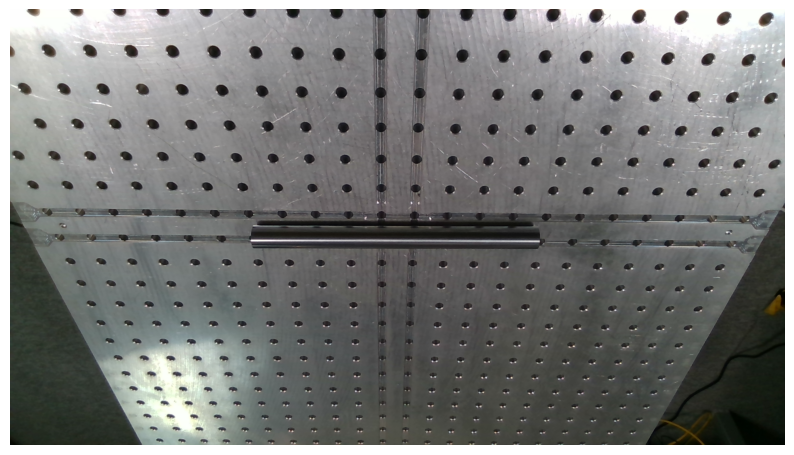

In [38]:
import json
import os
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

# Let's inspect scene 000300
scene_dir = '/content/DIMO/dimo/real_d415/000300'

# Load ground truth annotations
with open(os.path.join(scene_dir, 'scene_gt.json'), 'r') as f:
    scene_gt = json.load(f)

# Get the first image ID from the JSON keys (usually strings like '0', '1', etc.)
first_img_id = list(scene_gt.keys())[0]

# In BOP, images are usually 6-digit zero-padded names
img_name = f"{int(first_img_id):06d}.png"
img_path = os.path.join(scene_dir, 'rgb', img_name)

print(f"Visualizing image: {img_path}")

# Load and display the image
img = Image.open(img_path)
fig, ax = plt.subplots(1, figsize=(10, 8))
ax.imshow(img)

# Print the GT data for inspection
print(f"Ground Truth data for image {first_img_id}:")
print(json.dumps(scene_gt[first_img_id][:2], indent=2)) # Print first 2 objects to avoid spam

# BOP format usually stores bounding boxes as [xmin, ymin, width, height] either in scene_gt or scene_info
# Let's check scene_info just in case
with open(os.path.join(scene_dir, 'scene_info.json'), 'r') as f:
    scene_info = json.load(f)

if first_img_id in scene_gt:
    # Sometimes bounding boxes are in scene_gt (BOP newer format), sometimes in scene_info
    for i, obj in enumerate(scene_gt[first_img_id]):
        bb = None
        if 'obj_bb' in obj:
            bb = obj['obj_bb']
        elif first_img_id in scene_info:
            info = scene_info[first_img_id]
            if isinstance(info, list) and i < len(info) and 'bbox_obj' in info[i]:
                bb = info[i]['bbox_obj']

        if bb is not None:
            # Bounding box is [xmin, ymin, width, height]
            rect = patches.Rectangle((bb[0], bb[1]), bb[2], bb[3], linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(bb[0], bb[1]-5, f"Obj ID: {obj['obj_id']}", color='lime', fontsize=12, fontweight='bold')
        else:
            if i == 0:
                print("No bounding box data found in standard locations for this dataset.")

plt.axis('off')
plt.show()

In [39]:
# We will use trimesh to easily load the 3D .ply models
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 3.7 MB/s eta 0:00:00


### Step 7: Load Dataset using Official DIMO Loader
Instead of parsing JSONs manually, let's use the provided `dimo_loader.py` to structure the dataset.

In [44]:
import sys
import os
# Ensure the current directory is in the path to import dimo_loader
if '/content' not in sys.path:
    sys.path.append('/content')

from dimo_loader import DimoLoader
from pathlib import Path

# Set path to the extracted dimo dataset folder
dimo_path = Path('/content/DIMO/dimo')

print("Initializing DimoLoader...")
dimo_loader = DimoLoader()

print(f"Loading dataset from {dimo_path}...")
# Pass cameras=["real_d415"] to specify the folder to load instead of defaulting to real_jaigo
dimo_ds = dimo_loader.load(dimo_path, cameras=["real_d415"])

# Let's inspect what was loaded
print("\n--- Dataset Summary ---")
print("Top-level keys:", list(dimo_ds.keys()))
print(f"Number of 3D models loaded: {len(dimo_ds['models'])}")

# Now the data will be keyed as 'real_d415' and we know it's a list of scenes
real_scenes = dimo_ds['real_d415']

print(f"Number of scenes in 'real_d415': {len(real_scenes)}")

first_scene = real_scenes[0]
print(f"Scene ID {first_scene['id']} contains {len(first_scene['images'])} images.")

# Let's look at the first image's keys
first_img = first_scene['images'][0]
print(f"First image keys: {list(first_img.keys())}")
print(f"Number of objects in first image: {len(first_img['objects'])}")

Initializing DimoLoader...
Loading dataset from /content/DIMO/dimo...
Loading real_d415

--- Dataset Summary ---
Top-level keys: ['models', 'real_d415']
Number of 3D models loaded: 6
Number of scenes in 'real_d415': 600
Scene ID 000000 contains 13 images.
First image keys: ['id', 'path', 'camera', 'scene_info', 'objects']
Number of objects in first image: 1


Visualizing samples using DimoLoader structure...


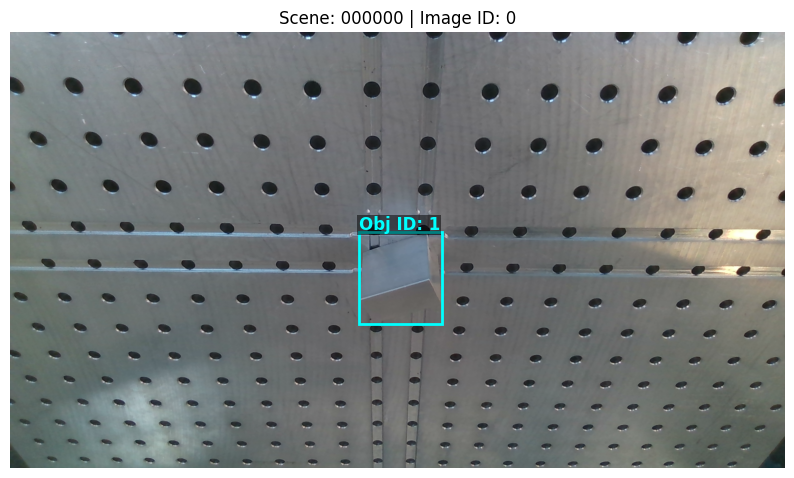

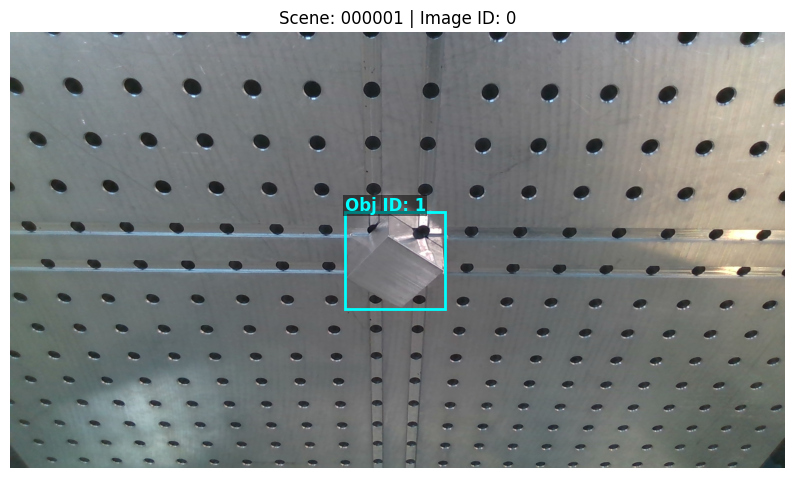

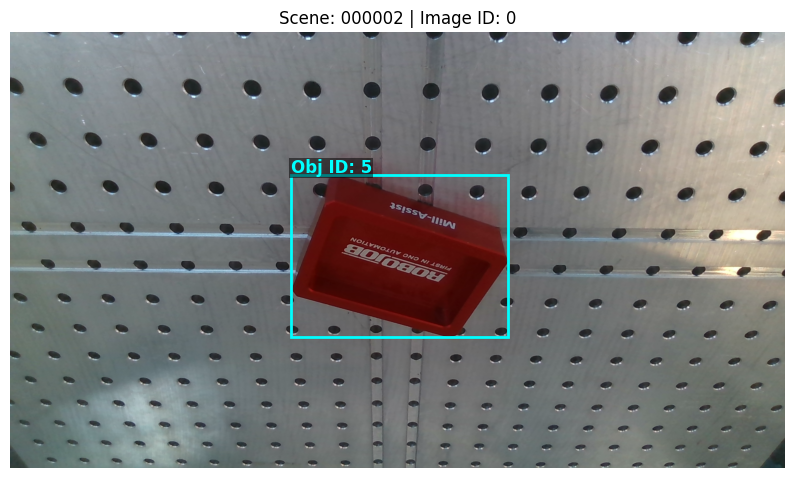

In [48]:
import numpy as np
import trimesh
import os
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

# Cache for 3D models to speed up projection across multiple images
models_dir = '/content/DIMO/dimo/models'
models_cache = {}

def get_model_vertices(obj_id):
    if obj_id not in models_cache:
        model_path = os.path.join(models_dir, f"obj_{int(obj_id):06d}.ply")
        mesh = trimesh.load(model_path)
        models_cache[obj_id] = mesh.vertices
    return models_cache[obj_id]

def visualize_loaded_sample(scene, img_idx=0):
    # Extract image metadata from the loader's structure
    img_data = scene['images'][img_idx]
    img_path = img_data['path']

    img = Image.open(img_path)
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)

    # Camera intrinsics matrix
    K = np.array(img_data['camera']['K']).reshape(3, 3)

    # Iterate through objects present in the image
    for obj in img_data['objects']:
        obj_id = obj['id']

        if 'model_2cam' in obj:
            pose = np.array(obj['model_2cam'])
            # Extract 3x3 Rotation and 3x1 translation from 4x4 matrix
            R = pose[:3, :3]
            t = pose[:3, 3].reshape(3, 1)
        else:
            print("No model_2cam found for object:", obj_id)
            continue

        # Load 3D vertices
        vertices = get_model_vertices(obj_id)

        # Project 3D points to 2D image plane
        pts_cam = (R @ vertices.T) + t
        pts_2d = K @ pts_cam

        # Normalize by depth (Z) to get pixel coordinates
        u = pts_2d[0, :] / pts_2d[2, :]
        v = pts_2d[1, :] / pts_2d[2, :]

        xmin, xmax = np.min(u), np.max(u)
        ymin, ymax = np.min(v), np.max(v)
        width, height = xmax - xmin, ymax - ymin

        # Draw the computed bounding box
        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='cyan', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, f"Obj ID: {obj_id}", color='cyan', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

    plt.title(f"Scene: {scene['id']} | Image ID: {img_data['id']}")
    plt.axis('off')
    plt.show()

# Let's visualize the first image from the first 3 scenes to verify
print("Visualizing samples using DimoLoader structure...")
for i in range(min(3, len(real_scenes))):
    visualize_loaded_sample(real_scenes[i], img_idx=0)